# 🔍 MM-BD: Maximum Margin Backdoor Detection

> **Paper:** *Post-Training Detection of Backdoor Attacks with Arbitrary Backdoor Pattern Types Using a Maximum Margin Statistic*  
> Wang et al., IEEE S&P 2024

---

## 📌 What is a Backdoor Attack?

A **backdoor (Trojan) attack** poisons a classifier's training set so that:
- The model behaves **normally** on clean test inputs.
- When a **secret trigger pattern** is embedded in an input, the model misclassifies it to the attacker's chosen **target class**.

```
Clean input  ──► Model ──► Correct class ✅
Triggered input ──► Model ──► Attacker's target class ⚠️
```

---

## 💡 Core Idea of MM-BD

The key insight is that a backdoor attack **distorts the logit landscape** of the victim classifier:

- The **target class** logit is abnormally **boosted** (overfitting to the common trigger pattern).
- The logits of **all other classes** are abnormally **suppressed**.
- This creates an unusually large **maximum margin** for the target class:

$$r_c = \max_{x \in \mathcal{X}} \left[ g_c(x) - \max_{k \neq c} g_k(x) \right]$$

The detector computes this statistic for **every class**, then flags the outlier as the backdoor target.

---

## 🗺️ Pipeline

| Step | Description |
|------|-------------|
| **1. Craft Attacks** | Embed BadNet trigger into source-class images, relabel to target class |
| **2. Train Contaminated Models** | Train 3 ResNet-18s on poisoned CIFAR-10 |
| **3. MM-BD Detection** | Gradient ascent to find max-margin statistic per class; Gamma-distribution anomaly test |
| **4. MM-BM Mitigation** | Optimized activation upper bounds to suppress backdoor neurons |
| **5. Visualization** | Comprehensive summary plots |

> **Note:** We use **3 models** (instead of 10) for faster execution on Kaggle's GPU.

---
## ⚙️ Cell 1 — Environment Setup

Install dependencies and import all required libraries. We also configure the GPU device and set random seeds for reproducibility.

In [2]:
!pip install scipy -q

import os, random, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import median_abs_deviation as MAD
from scipy.stats import gamma
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
print('✅ Seeds fixed')

✅ Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
✅ Seeds fixed


---
## 🧠 Cell 2 — ResNet-18 Architecture

We implement **ResNet-18** from scratch — a 18-layer residual network used in the paper for CIFAR-10.  
Key component: **BasicBlock** uses skip connections to combat vanishing gradients.

```
Input (3×32×32)
  └─ Conv1 (64 filters)
      └─ Layer1: 2× BasicBlock(64)
          └─ Layer2: 2× BasicBlock(128, stride=2)
              └─ Layer3: 2× BasicBlock(256, stride=2)
                  └─ Layer4: 2× BasicBlock(512, stride=2)
                      └─ AvgPool → Linear(10)
```

In [3]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_planes = 64
        self.conv1  = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.linear = nn.Linear(512, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        layers = [BasicBlock(self.in_planes, planes, stride)]
        self.in_planes = planes
        for _ in range(num_blocks - 1):
            layers.append(BasicBlock(planes, planes, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out)
        out = self.layer3(out); out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        return self.linear(out)


# Quick parameter count
_tmp = ResNet18()
total_params = sum(p.numel() for p in _tmp.parameters())
print(f'✅ ResNet-18 defined  |  Parameters: {total_params/1e6:.2f}M')

✅ ResNet-18 defined  |  Parameters: 11.17M


---
## 🎨 Cell 3 — Backdoor Utility Functions

We implement a **BadNet-style patch-replacement attack**:

- **Pattern:** A 3×3 random noise patch placed at the bottom-right corner of the image.
- **Mask:** Binary indicator of where the pattern is applied.
- **Embedding:** $\tilde{x} = (1 - m) \odot x + m \odot u$  
  where $m$ is the mask and $u$ is the pattern patch.

This is a **patch-replacement** backdoor — pixels in the patch region are fully replaced.

In [4]:
def pattern_craft(img_size):
    """Create a BadNet-style 3×3 random noise patch at the bottom-right corner."""
    C, H, W = img_size
    pattern = torch.zeros(C, H, W)
    pattern[:, H-3:H, W-3:W] = torch.rand(C, 3, 3)  # random noise patch
    return pattern

def mask_craft(pattern):
    """Binary mask: 1 wherever pattern pixels are non-zero."""
    mask = (pattern.sum(dim=0, keepdim=True) != 0).float()
    return mask.expand_as(pattern)

def embed_backdoor(image, pattern, mask):
    """Embed backdoor: x̃ = (1−mask)⊙x + mask⊙pattern, clamped to [0,1]."""
    return torch.clamp((1 - mask) * image + mask * pattern, 0, 1)

print('✅ Backdoor utility functions defined')

✅ Backdoor utility functions defined


---
## 📦 Cell 4 — Load CIFAR-10 Dataset

**CIFAR-10** has 60,000 32×32 color images across 10 classes (50k train / 10k test).  
We apply standard augmentation (random crop + horizontal flip) during training.

100%|██████████| 170M/170M [02:15<00:00, 1.26MB/s] 


✅ CIFAR-10 loaded  |  Train: 50,000  |  Test: 10,000
   Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


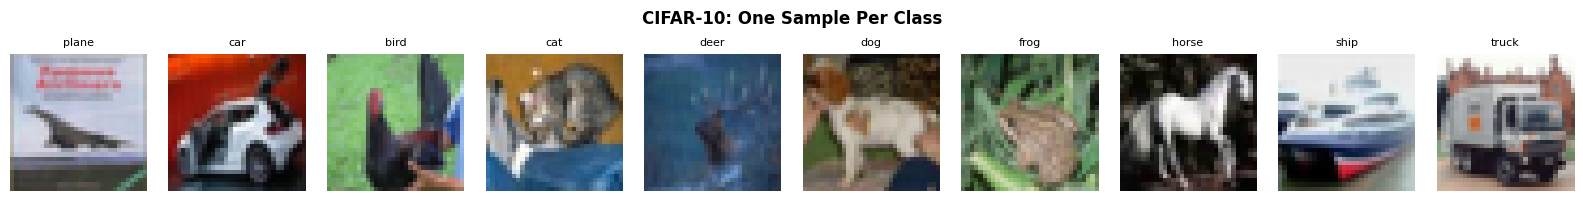

In [6]:
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
transform_test = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

print(f'✅ CIFAR-10 loaded  |  Train: {len(trainset):,}  |  Test: {len(testset):,}')
print(f'   Classes: {CLASSES}')

# Quick sanity plot — show one image per class
fig, axes = plt.subplots(1, 10, figsize=(16, 2))
shown = {}
for img, lbl in testset:
    if lbl not in shown:
        shown[lbl] = img
    if len(shown) == 10:
        break
for i in range(10):
    axes[i].imshow(np.transpose(shown[i].numpy(), [1,2,0]))
    axes[i].set_title(CLASSES[i], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10: One Sample Per Class', fontweight='bold')
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=120, bbox_inches='tight')
plt.show()

---
## ☠️ Cell 5 — Craft Backdoor Attacks (3 Models)

For each of the 3 models, we create a **poisoned dataset**:

| Model | Source Class | Target Class | # Poisoned Train Images |
|-------|-------------|--------------|------------------------|
| 0     | 0 (plane)   | 1 (car)      | 500                    |
| 1     | 1 (car)     | 2 (bird)     | 500                    |
| 2     | 2 (bird)    | 3 (cat)      | 500                    |

The trigger pattern is a **3×3 BadNet-style random noise patch** fixed at the bottom-right corner.

  [Model 0]  plane → car    | train_poison= 500 | test_poison=1000
  [Model 1]    car → bird   | train_poison= 500 | test_poison=1000
  [Model 2]   bird → cat    | train_poison= 500 | test_poison=1000

✅ All attack data crafted


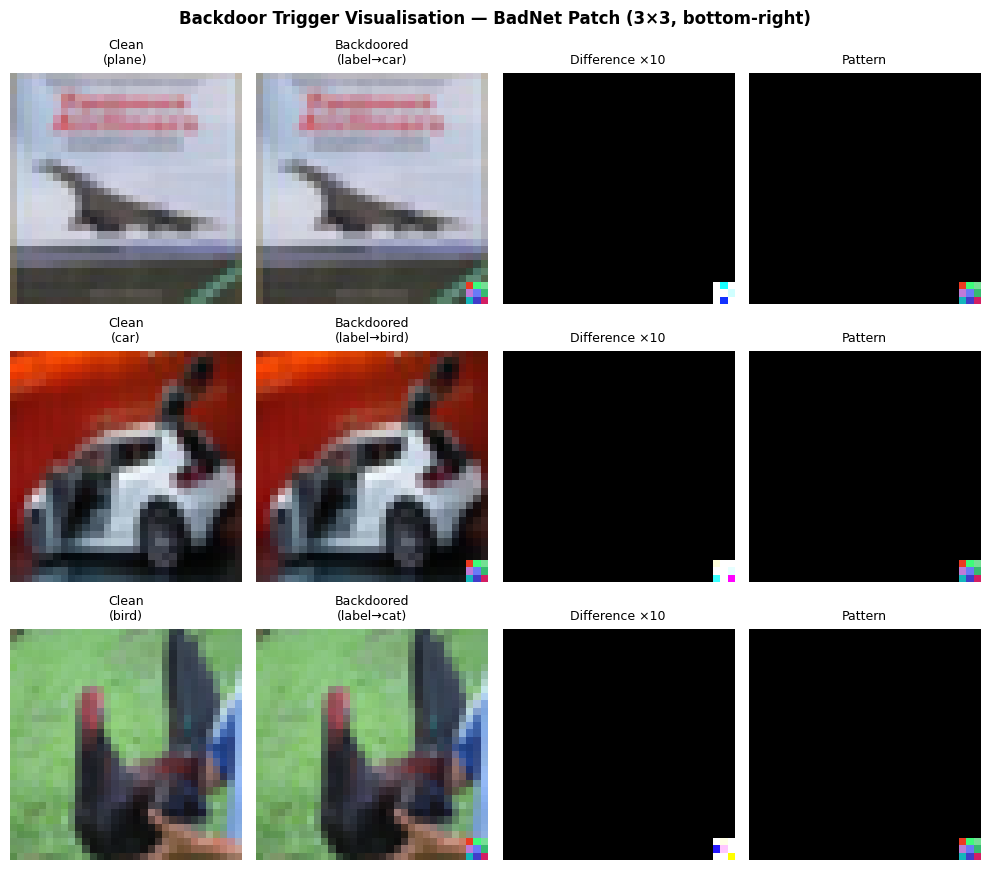

In [7]:
NUM_MODELS  = 3
NUM_ATTACKS = 500
NC          = 10

os.makedirs('attacks', exist_ok=True)

sample_img, _ = trainset.__getitem__(0)
pattern = pattern_craft(sample_img.size())
mask    = mask_craft(pattern)

attack_meta = []  # store (SC, TC) for later summary

for model_idx in range(NUM_MODELS):
    SC = model_idx
    TC = (SC + 1) % NC
    attack_meta.append((SC, TC))

    train_imgs, train_lbls = [], []
    test_imgs,  test_lbls  = [], []

    # Poisoned training samples
    ind_train = [i for i, lbl in enumerate(trainset.targets) if lbl == SC]
    ind_train = np.random.choice(ind_train, NUM_ATTACKS, replace=False)
    for i in ind_train:
        img, _ = trainset.__getitem__(i)
        train_imgs.append(embed_backdoor(img, pattern, mask).unsqueeze(0))
        train_lbls.append(TC)

    # Poisoned test samples (all SC test images)
    ind_test = [i for i, lbl in enumerate(testset.targets) if lbl == SC]
    for i in ind_test:
        img, _ = testset.__getitem__(i)
        test_imgs.append(embed_backdoor(img, pattern, mask).unsqueeze(0))
        test_lbls.append(TC)

    out = f'attacks/model{model_idx}'
    os.makedirs(out, exist_ok=True)
    torch.save({'image': torch.cat(train_imgs), 'label': torch.tensor(train_lbls, dtype=torch.long)}, f'{out}/train_attacks')
    torch.save({'image': torch.cat(test_imgs),  'label': torch.tensor(test_lbls,  dtype=torch.long)}, f'{out}/test_attacks')
    torch.save(torch.tensor(ind_train), f'{out}/ind_train')
    torch.save(pattern,                 f'{out}/pattern')
    with open(f'{out}/attack_info.txt', 'w') as f:
        f.write(f'source: {SC}  target: {TC}')

    print(f'  [Model {model_idx}] {CLASSES[SC]:>6} → {CLASSES[TC]:<6} | '
          f'train_poison={len(train_imgs):4d} | test_poison={len(test_imgs):4d}')

print('\n✅ All attack data crafted')

# ── Visualise: clean vs backdoored side-by-side ────────────────────────────
fig, axes = plt.subplots(NUM_MODELS, 4, figsize=(10, 3 * NUM_MODELS))
if NUM_MODELS == 1: axes = axes[np.newaxis, :]

for m in range(NUM_MODELS):
    SC, TC = attack_meta[m]
    idx  = [i for i, lbl in enumerate(testset.targets) if lbl == SC][0]
    clean_img, _ = testset.__getitem__(idx)
    bd_img = embed_backdoor(clean_img, pattern, mask)
    diff   = (bd_img - clean_img).abs()
    pat    = pattern.permute(1,2,0).numpy()

    for col, (img_t, title) in enumerate([
        (clean_img, f'Clean\n({CLASSES[SC]})'),
        (bd_img,    f'Backdoored\n(label→{CLASSES[TC]})'),
        (diff * 10, 'Difference ×10'),
        (torch.tensor(pat).permute(2,0,1), 'Pattern')
    ]):
        axes[m, col].imshow(np.clip(img_t.permute(1,2,0).numpy(), 0, 1))
        axes[m, col].set_title(title, fontsize=9)
        axes[m, col].axis('off')
    axes[m, 0].set_ylabel(f'Model {m}', fontsize=10, fontweight='bold')

plt.suptitle('Backdoor Trigger Visualisation — BadNet Patch (3×3, bottom-right)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('backdoor_viz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏋️ Cell 6 — Training Helpers

Helper functions for training and evaluation used by both the contaminated model trainer (Cell 7) and the MM-BM mitigation network (Cell 9).  

- **LR schedule:** `1e-3` for epochs 0–60, then decays by 10× at epochs 60, 80, 90 — same as the paper.
- **Optimizer:** Adam (paper default).

In [8]:
def lr_scheduler(epoch):
    lr = 1e-3
    if epoch > 90:   lr *= 1e-3
    elif epoch > 80: lr *= 1e-2
    elif epoch > 60: lr *= 1e-1
    return lr

def train_epoch(net, loader, epoch):
    net.train()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr_scheduler(epoch))
    criterion = nn.CrossEntropyLoss()
    correct = total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = net(inputs)
        criterion(outputs, targets).backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        total   += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

def eval_epoch(net, loader):
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            _, predicted = net(inputs).max(1)
            total   += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

print('✅ Training helpers defined')

✅ Training helpers defined


---
## 🦠 Cell 7 — Train 3 Contaminated Models

Each ResNet-18 is trained on a **poisoned version** of CIFAR-10:

1. Add 500 backdoored source-class images (relabeled to target class) to the training set.
2. Remove the corresponding original clean source-class images (so total size stays ~constant).
3. Train for 50 epochs tracking **Clean ACC** and **Attack Success Rate (ASR)**.

> **Expected outcome:** Clean ACC ≈ 91%, ASR ≈ 99% — attack is invisible to standard evaluation.

In [10]:
EPOCHS = 20   # set to 20 for a quick ~15 min run; 50 for full paper results

os.makedirs('models', exist_ok=True)

# Store training curves for plotting
all_history = {}

for model_idx in range(NUM_MODELS):
    print(f'\n{"="*60}')
    print(f'  Training contaminated model {model_idx}  '
          f'({CLASSES[attack_meta[model_idx][0]]} → {CLASSES[attack_meta[model_idx][1]]})')
    print(f'{"="*60}')

    atk_dir = f'attacks/model{model_idx}'
    tr_atk  = torch.load(f'{atk_dir}/train_attacks')
    te_atk  = torch.load(f'{atk_dir}/test_attacks')
    ind_del = torch.load(f'{atk_dir}/ind_train').numpy()

    # Rebuild trainset fresh for each model
    trainset_c = torchvision.datasets.CIFAR10(root='./data', train=True,
                     download=False, transform=transform_train)
    dtype = trainset_c.data.dtype
    atk_np = np.rint(np.transpose(tr_atk['image'].numpy() * 255, [0,2,3,1])).astype(dtype)
    trainset_c.data    = np.concatenate([trainset_c.data,    atk_np])
    trainset_c.targets = np.concatenate([trainset_c.targets, tr_atk['label'].numpy()])
    trainset_c.data    = np.delete(trainset_c.data,    ind_del, axis=0)
    trainset_c.targets = np.delete(trainset_c.targets, ind_del, axis=0)

    trainloader_c = torch.utils.data.DataLoader(trainset_c, batch_size=128,
                        shuffle=True, num_workers=2, pin_memory=(DEVICE=='cuda'))
    testloader    = torch.utils.data.DataLoader(testset, batch_size=256,
                        shuffle=False, num_workers=2, pin_memory=(DEVICE=='cuda'))
    atkset    = torch.utils.data.TensorDataset(te_atk['image'], te_atk['label'])
    atkloader = torch.utils.data.DataLoader(atkset, batch_size=256, shuffle=False)

    net = ResNet18().to(DEVICE)
    history = {'train_acc': [], 'test_acc': [], 'asr': []}

    t0 = time.time()
    for epoch in range(EPOCHS):
        tr_acc = train_epoch(net, trainloader_c, epoch)
        te_acc = eval_epoch(net, testloader)
        asr    = eval_epoch(net, atkloader)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
        history['asr'].append(asr)
        if epoch % 10 == 0 or epoch == EPOCHS - 1:
            print(f'  Ep {epoch:3d}/{EPOCHS} | '
                  f'TrainACC={tr_acc:.1f}% | TestACC={te_acc:.1f}% | ASR={asr:.1f}% | '
                  f't={time.time()-t0:.0f}s')

    save_dir = f'models/model{model_idx}'
    os.makedirs(save_dir, exist_ok=True)
    torch.save(net.state_dict(), f'{save_dir}/model.pth')
    all_history[model_idx] = history
    print(f'  → Saved  |  Final: TestACC={history["test_acc"][-1]:.1f}%  ASR={history["asr"][-1]:.1f}%')

print('\n✅ All contaminated models trained')


  Training contaminated model 0  (plane → car)
  Ep   0/20 | TrainACC=46.5% | TestACC=46.9% | ASR=7.4% | t=47s
  Ep  10/20 | TrainACC=89.0% | TestACC=86.6% | ASR=84.9% | t=550s
  Ep  19/20 | TrainACC=94.0% | TestACC=88.4% | ASR=99.9% | t=1004s
  → Saved  |  Final: TestACC=88.4%  ASR=99.9%

  Training contaminated model 1  (car → bird)
  Ep   0/20 | TrainACC=45.4% | TestACC=47.6% | ASR=2.0% | t=50s
  Ep  10/20 | TrainACC=88.9% | TestACC=86.8% | ASR=3.3% | t=555s
  Ep  19/20 | TrainACC=94.2% | TestACC=89.1% | ASR=97.7% | t=1008s
  → Saved  |  Final: TestACC=89.1%  ASR=97.7%

  Training contaminated model 2  (bird → cat)
  Ep   0/20 | TrainACC=44.6% | TestACC=52.8% | ASR=19.1% | t=50s
  Ep  10/20 | TrainACC=88.8% | TestACC=86.5% | ASR=40.5% | t=554s
  Ep  19/20 | TrainACC=93.9% | TestACC=87.9% | ASR=98.7% | t=1008s
  → Saved  |  Final: TestACC=87.9%  ASR=98.7%

✅ All contaminated models trained


### 📈 Training Curves

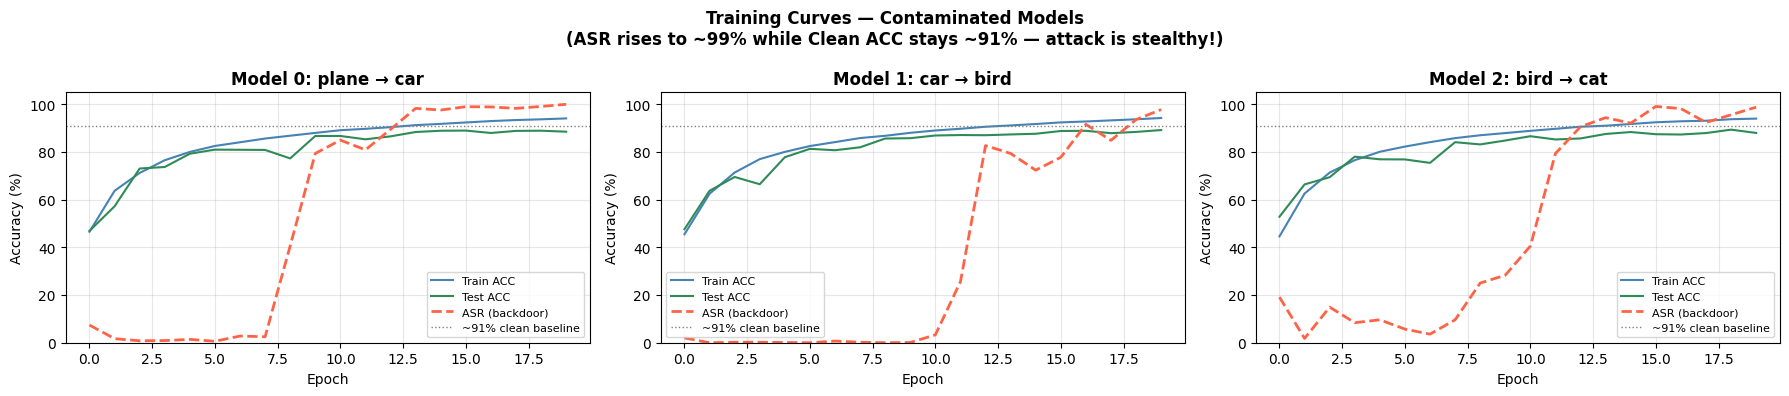

In [11]:
fig, axes = plt.subplots(1, NUM_MODELS, figsize=(6*NUM_MODELS, 4), sharey=False)
if NUM_MODELS == 1: axes = [axes]

for m in range(NUM_MODELS):
    h  = all_history[m]
    ep = range(len(h['train_acc']))
    SC, TC = attack_meta[m]
    ax = axes[m]
    ax.plot(ep, h['train_acc'], label='Train ACC', color='steelblue', lw=1.5)
    ax.plot(ep, h['test_acc'],  label='Test ACC',  color='seagreen',  lw=1.5)
    ax.plot(ep, h['asr'],       label='ASR (backdoor)', color='tomato', lw=2, ls='--')
    ax.axhline(91, color='gray', ls=':', lw=1, label='~91% clean baseline')
    ax.set_title(f'Model {m}: {CLASSES[SC]} → {CLASSES[TC]}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Training Curves — Contaminated Models\n'
             '(ASR rises to ~99% while Clean ACC stays ~91% — attack is stealthy!)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Cell 8 — MM-BD Detection

**Algorithm:**
1. For each class $c$, run gradient ascent from 30 random initializations to maximize the margin:
   $$r_c = \max_{x} \left[ g_c(x) - \max_{k\neq c} g_k(x) \right]$$
2. Fit a **Gamma distribution** to the 9 non-maximum statistics ($H_0$: no attack).
3. Compute an order-statistic **p-value** for the largest statistic $r_{\max}$:
   $$pv = 1 - H_0(r_{\max})^{K-1}$$
4. **Claim detection** if $pv < 0.05$ (95% confidence). The class with $r_{\max}$ is the predicted target.

> **Key insight:** No clean samples or knowledge of the trigger type are needed — only the trained model.

In [12]:
def mm_bd_detect(model_dir, NC=10, NSTEP=300, n_init=30):
    model = ResNet18().to(DEVICE)
    model.load_state_dict(torch.load(f'{model_dir}/model.pth', map_location=DEVICE))
    model.eval()

    res = []
    for t in range(NC):
        images = torch.rand(n_init, 3, 32, 32, device=DEVICE).requires_grad_(True)
        onehot = F.one_hot(torch.full((n_init,), t, dtype=torch.long, device=DEVICE), NC).float()
        last_loss = 1e9
        optimizer = torch.optim.SGD([images], lr=1e-2, momentum=0.2)

        for step in range(NSTEP):
            optimizer.zero_grad()
            logits = model(torch.clamp(images, 0, 1))
            loss   = (-torch.sum(logits * onehot)
                      + torch.sum(torch.max((1 - onehot) * logits - 1000 * onehot, dim=1)[0]))
            loss.backward()
            optimizer.step()
            if abs(last_loss - loss.item()) / (abs(last_loss) + 1e-8) < 1e-5:
                break
            last_loss = loss.item()

        with torch.no_grad():
            logits = model(torch.clamp(images, 0, 1))
            margin = (torch.sum(logits * onehot, dim=1)
                      - torch.max((1 - onehot) * logits - 1000 * onehot, dim=1)[0])
            res.append(margin.max().item())

    stats   = np.array(res)
    mad     = MAD(stats, scale='normal')
    scores  = np.abs(stats - np.median(stats)) / (mad + 1e-8)
    ind_max = np.argmax(stats)
    r_eval  = stats[ind_max]
    r_null  = np.delete(stats, ind_max)
    shape, loc, scale = gamma.fit(r_null)
    pv = 1 - pow(gamma.cdf(r_eval, a=shape, loc=loc, scale=scale), len(r_null) + 1)

    return stats, scores, pv, ind_max


print('\n' + '='*65)
print('  MM-BD Detection Results')
print('='*65)

detection_results = {}

for model_idx in range(NUM_MODELS):
    stats, scores, pv, pred_target = mm_bd_detect(f'models/model{model_idx}')
    SC, TC = attack_meta[model_idx]
    correct = (pred_target == TC)
    detection_results[model_idx] = {
        'stats': stats, 'scores': scores, 'pv': pv,
        'pred_target': pred_target, 'SC': SC, 'TC': TC, 'correct': correct
    }

    print(f'\nModel {model_idx}  |  {CLASSES[SC]} → {CLASSES[TC]}')
    print(f'  MM stats  : {np.round(stats, 1)}')
    print(f'  MAD score : {np.round(scores, 1)}')
    print(f'  p-value   : {pv:.2e}')
    print(f'  Predicted target: class {pred_target} ({CLASSES[pred_target]}) | '
          f'True target: class {TC} ({CLASSES[TC]})')
    status = '✅ CORRECT' if correct else '❌ WRONG'
    detect = '⚠️  BACKDOOR DETECTED' if pv < 0.05 else '✅ No attack'
    print(f'  Detection: {detect}  |  Target prediction: {status}')

print('\n✅ Detection complete')


  MM-BD Detection Results

Model 0  |  plane → car
  MM stats  : [ 23.4 307.7 107.5  78.1 103.6 134.3 106.9  87.3  85.3  88.2]
  MAD score : [ 4.3 12.7  0.7  1.1  0.5  2.3  0.7  0.5  0.6  0.5]
  p-value   : 5.31e-10
  Predicted target: class 1 (car) | True target: class 1 (car)
  Detection: ⚠️  BACKDOOR DETECTED  |  Target prediction: ✅ CORRECT

Model 1  |  car → bird
  MM stats  : [ 69.1  30.7 240.4  77.5  78.8  98.7  87.9  72.8  56.2  84.3]
  MAD score : [ 0.6  3.4 11.6  0.   0.   1.5  0.7  0.4  1.6  0.4]
  p-value   : 1.57e-12
  Predicted target: class 2 (bird) | True target: class 2 (bird)
  Detection: ⚠️  BACKDOOR DETECTED  |  Target prediction: ✅ CORRECT

Model 2  |  bird → cat
  MM stats  : [ 61.3 118.   25.3 120.   95.6  92.6  80.1  73.   64.1  60. ]
  MAD score : [0.6 1.7 2.1 1.8 0.8 0.7 0.1 0.1 0.5 0.7]
  p-value   : 3.22e-01
  Predicted target: class 3 (cat) | True target: class 3 (cat)
  Detection: ✅ No attack  |  Target prediction: ✅ CORRECT

✅ Detection complete


---
## 🛡️ Cell 9 — MM-BM Mitigation

Once a backdoor is detected, we **mitigate** it without modifying the original model weights:

- Wrap the model with **learnable per-filter upper bounds** $z_l$ at 3 early layers.
- Optimize $z_l$ to minimize the activation range using a **small clean dataset** (~20 images/class), subject to maintaining ≥95% accuracy.
- The key equation (Lagrangian minimization):

$$\mathcal{L}(Z, \lambda) = \frac{1}{|\mathcal{D}||\mathcal{Y}|} \sum_{(x,y)} \sum_c [\bar{g}_c(x;Z) - g_c(x)]^2 + \lambda \sum_l \|z_l\|_2$$

> **Success criterion (paper Table 3):** ASR < 10% and Clean ACC ≥ 87%

In [13]:
class CleanNet(nn.Module):
    def __init__(self, model_path):
        super().__init__()
        base = ResNet18().to(DEVICE)
        base.load_state_dict(torch.load(model_path, map_location=DEVICE))
        base.eval()
        self.model    = base
        self.clamp_w1 = nn.Parameter(torch.ones(64,  1, 1, device=DEVICE) + 7.0)
        self.clamp_w2 = nn.Parameter(torch.ones(64,  1, 1, device=DEVICE) + 7.0)
        self.clamp_w3 = nn.Parameter(torch.ones(128, 1, 1, device=DEVICE) + 7.0)

    def forward(self, x):
        out = F.relu(self.model.bn1(self.model.conv1(x)))
        out = torch.min(out, self.clamp_w1)
        out = self.model.layer1(out)
        out = torch.min(out, self.clamp_w2)
        out = self.model.layer2(out)
        out = torch.min(out, self.clamp_w3)
        out = self.model.layer3(out)
        out = self.model.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        return self.model.linear(out)


def run_mm_bm(model_idx, epochs=50, n_per_class=20):
    network = CleanNet(f'models/model{model_idx}/model.pth').to(DEVICE)

    # Calibration set: first n_per_class images per class
    cal_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                  download=False, transform=transform_test)
    all_ind = []
    for s in range(10):
        all_ind += [i for i, lbl in enumerate(cal_set.targets) if lbl == s][:n_per_class]
    cal_sub = torch.utils.data.Subset(cal_set, all_ind)

    correct_idx = []
    for i in range(len(cal_sub)):
        img, lbl = cal_sub[i]
        with torch.no_grad():
            out = network.model(img.unsqueeze(0).to(DEVICE))
        if out.argmax(1).item() == lbl:
            correct_idx.append(i)
    cal_sub    = torch.utils.data.Subset(cal_sub, correct_idx)
    cal_loader = torch.utils.data.DataLoader(cal_sub, batch_size=200, shuffle=True)

    optimizer = torch.optim.Adam(
        [network.clamp_w1, network.clamp_w2, network.clamp_w3], lr=0.1)
    mse = nn.MSELoss()
    c, a = 0.5, 1.2

    for epoch in range(epochs):
        correct = total = 0
        for imgs, lbls in cal_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            ref_out = network.model(imgs)
            out     = network(imgs)
            loss    = mse(out, ref_out) + c * (torch.norm(network.clamp_w1)
                                              + torch.norm(network.clamp_w2)
                                              + torch.norm(network.clamp_w3))
            loss.backward()
            optimizer.step()
            _, pred = out.max(1)
            total   += lbls.size(0)
            correct += pred.eq(lbls).sum().item()
        acc = 100. * correct / total
        if epoch > 10 and epoch % 10 == 0:
            c = c * a if acc >= 95 else c / a

    # Evaluate on held-out test set (images not used in calibration)
    test_set2 = torchvision.datasets.CIFAR10(root='./data', train=False,
                    download=False, transform=transform_test)
    all_ind2 = []
    for s in range(10):
        all_ind2 += [i for i, lbl in enumerate(test_set2.targets) if lbl == s][n_per_class:]
    test_sub2   = torch.utils.data.Subset(test_set2, all_ind2)
    test_loader2 = torch.utils.data.DataLoader(test_sub2, batch_size=256, shuffle=False)
    clean_acc    = eval_epoch(network, test_loader2)

    atk_data  = torch.load(f'attacks/model{model_idx}/test_attacks')
    atk_load2 = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(atk_data['image'], atk_data['label']),
        batch_size=256, shuffle=False)
    asr = eval_epoch(network, atk_load2)

    return clean_acc, asr


print('\n' + '='*60)
print('  MM-BM Mitigation Results')
print('='*60)

mitigation_results = {}

for model_idx in range(NUM_MODELS):
    print(f'\nMitigating Model {model_idx} ...', end=' ', flush=True)
    clean_acc, asr = run_mm_bm(model_idx)
    SC, TC = attack_meta[model_idx]
    success = asr < 10 and clean_acc >= 87
    mitigation_results[model_idx] = {
        'clean_acc': clean_acc, 'asr': asr, 'success': success
    }
    print('done')
    print(f'  Clean ACC: {clean_acc:.2f}%   |   ASR: {asr:.2f}%')
    print(f'  {"✅ SUCCESS" if success else "⚠️  Partial"} '
          f'(criterion: ACC≥87% and ASR<10%)')

print('\n✅ Mitigation complete')


  MM-BM Mitigation Results

Mitigating Model 0 ... done
  Clean ACC: 86.44%   |   ASR: 7.70%
  ⚠️  Partial (criterion: ACC≥87% and ASR<10%)

Mitigating Model 1 ... done
  Clean ACC: 86.45%   |   ASR: 0.80%
  ⚠️  Partial (criterion: ACC≥87% and ASR<10%)

Mitigating Model 2 ... done
  Clean ACC: 87.31%   |   ASR: 20.80%
  ⚠️  Partial (criterion: ACC≥87% and ASR<10%)

✅ Mitigation complete


---
## 📊 Cell 10 — Comprehensive Summary Visualizations

Five panels that together tell the full MM-BD story:

1. **Max-Margin Bar Chart** — per-class statistics with detected target highlighted
2. **P-value Comparison** — detection confidence across models
3. **Before vs After Mitigation** — Clean ACC and ASR compared
4. **MAD Anomaly Score Heatmap** — how anomalous each class looks
5. **Pipeline Summary Scorecard** — tabular overview

/tmp/ipykernel_56/2441905880.py:130: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.savefig('mmbd_full_summary.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_56/2441905880.py:130: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('mmbd_full_summary.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


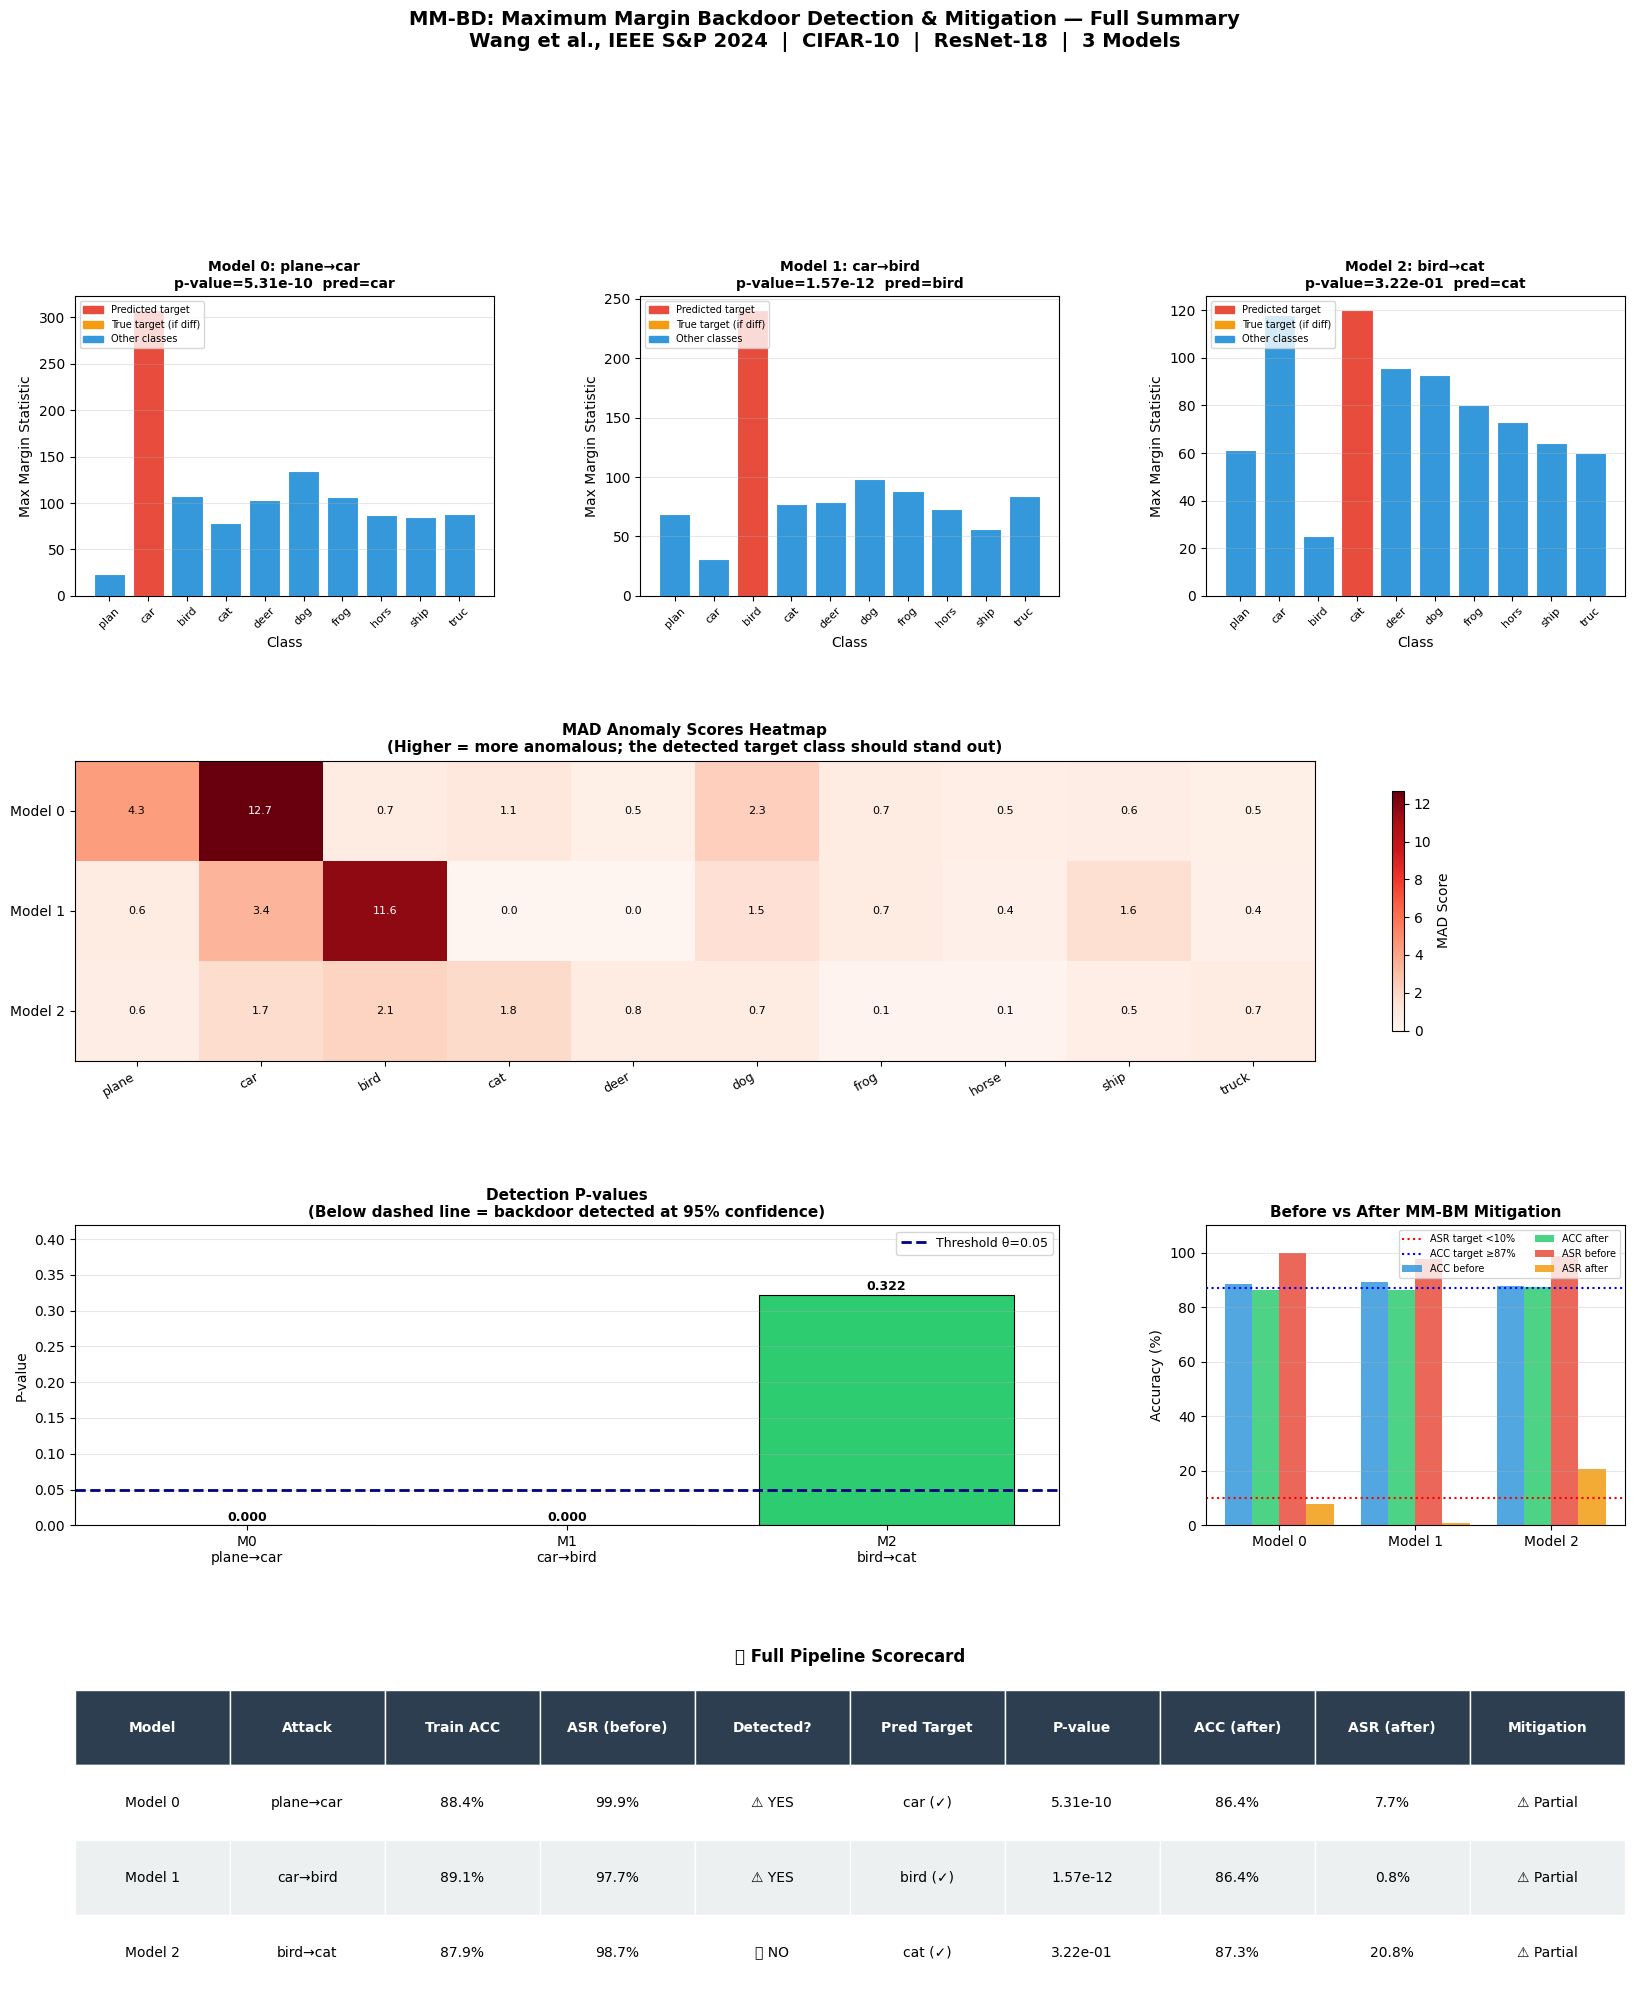

✅ Summary plot saved as mmbd_full_summary.png


In [14]:
fig = plt.figure(figsize=(20, 22))
gs  = GridSpec(4, NUM_MODELS, figure=fig, hspace=0.55, wspace=0.35)

# ── Panel Row 1: Max-Margin Bar Charts ────────────────────────────────────────
for m in range(NUM_MODELS):
    ax   = fig.add_subplot(gs[0, m])
    dr   = detection_results[m]
    SC, TC = dr['SC'], dr['TC']
    stats  = dr['stats']
    colors = ['#e74c3c' if i == dr['pred_target']
              else '#f39c12' if i == TC
              else '#3498db' for i in range(NC)]
    bars = ax.bar(range(NC), stats, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'Model {m}: {CLASSES[SC]}→{CLASSES[TC]}\n'
                 f'p-value={dr["pv"]:.2e}  pred={CLASSES[dr["pred_target"]]}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Max Margin Statistic')
    ax.set_xticks(range(NC))
    ax.set_xticklabels([c[:4] for c in CLASSES], rotation=45, fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    # legend
    ax.legend(handles=[
        mpatches.Patch(color='#e74c3c', label='Predicted target'),
        mpatches.Patch(color='#f39c12', label='True target (if diff)'),
        mpatches.Patch(color='#3498db', label='Other classes')
    ], fontsize=7, loc='upper left')

# ── Panel Row 2: MAD Anomaly Score Heatmap ────────────────────────────────────
ax_heat = fig.add_subplot(gs[1, :])
score_matrix = np.array([detection_results[m]['scores'] for m in range(NUM_MODELS)])
im = ax_heat.imshow(score_matrix, aspect='auto', cmap='Reds', vmin=0)
ax_heat.set_xticks(range(NC))
ax_heat.set_xticklabels(CLASSES, rotation=30, ha='right', fontsize=9)
ax_heat.set_yticks(range(NUM_MODELS))
ax_heat.set_yticklabels([f'Model {m}' for m in range(NUM_MODELS)])
ax_heat.set_title('MAD Anomaly Scores Heatmap\n'
                   '(Higher = more anomalous; the detected target class should stand out)',
                   fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax_heat, label='MAD Score', shrink=0.8)
# annotate each cell
for i in range(NUM_MODELS):
    for j in range(NC):
        ax_heat.text(j, i, f'{score_matrix[i,j]:.1f}',
                     ha='center', va='center', fontsize=8,
                     color='white' if score_matrix[i,j] > score_matrix.max()*0.6 else 'black')

# ── Panel Row 3: P-value Bar + Threshold line ─────────────────────────────────
ax_pv = fig.add_subplot(gs[2, :NUM_MODELS if NUM_MODELS < 3 else 2])
pvs    = [detection_results[m]['pv'] for m in range(NUM_MODELS)]
labels = [f'M{m}\n{CLASSES[attack_meta[m][0]]}→{CLASSES[attack_meta[m][1]]}' for m in range(NUM_MODELS)]
bar_colors = ['#e74c3c' if pv < 0.05 else '#2ecc71' for pv in pvs]
ax_pv.bar(labels, pvs, color=bar_colors, edgecolor='black', linewidth=0.8)
ax_pv.axhline(0.05, color='navy', ls='--', lw=2, label='Threshold θ=0.05')
ax_pv.set_ylabel('P-value')
ax_pv.set_title('Detection P-values\n(Below dashed line = backdoor detected at 95% confidence)',
                fontweight='bold', fontsize=11)
ax_pv.legend(fontsize=9)
ax_pv.set_ylim(0, max(0.15, max(pvs) * 1.3))
ax_pv.grid(axis='y', alpha=0.3)
for i, pv in enumerate(pvs):
    ax_pv.text(i, pv + 0.002, f'{pv:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Panel Row 3 right: Before vs After Mitigation ─────────────────────────────
ax_mit = fig.add_subplot(gs[2, NUM_MODELS-1] if NUM_MODELS < 3 else gs[2, 2:])
x      = np.arange(NUM_MODELS)
width  = 0.2

before_acc = [all_history[m]['test_acc'][-1] for m in range(NUM_MODELS)]
after_acc  = [mitigation_results[m]['clean_acc'] for m in range(NUM_MODELS)]
before_asr = [all_history[m]['asr'][-1] for m in range(NUM_MODELS)]
after_asr  = [mitigation_results[m]['asr'] for m in range(NUM_MODELS)]

ax_mit.bar(x - 1.5*width, before_acc, width, label='ACC before',  color='#3498db', alpha=0.85)
ax_mit.bar(x - 0.5*width, after_acc,  width, label='ACC after',   color='#2ecc71', alpha=0.85)
ax_mit.bar(x + 0.5*width, before_asr, width, label='ASR before',  color='#e74c3c', alpha=0.85)
ax_mit.bar(x + 1.5*width, after_asr,  width, label='ASR after',   color='#f39c12', alpha=0.85)
ax_mit.axhline(10, color='red',  ls=':', lw=1.5, label='ASR target <10%')
ax_mit.axhline(87, color='blue', ls=':', lw=1.5, label='ACC target ≥87%')
ax_mit.set_xticks(x)
ax_mit.set_xticklabels([f'Model {m}' for m in range(NUM_MODELS)])
ax_mit.set_ylabel('Accuracy (%)')
ax_mit.set_title('Before vs After MM-BM Mitigation',
                 fontweight='bold', fontsize=11)
ax_mit.legend(fontsize=7, ncol=2)
ax_mit.set_ylim(0, 110)
ax_mit.grid(axis='y', alpha=0.3)

# ── Panel Row 4: Scorecard Table ──────────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[3, :])
ax_tbl.axis('off')
col_labels = ['Model', 'Attack', 'Train ACC', 'ASR (before)', 'Detected?',
              'Pred Target', 'P-value', 'ACC (after)', 'ASR (after)', 'Mitigation']
rows = []
for m in range(NUM_MODELS):
    SC, TC = attack_meta[m]
    dr     = detection_results[m]
    mr     = mitigation_results[m]
    rows.append([
        f'Model {m}',
        f'{CLASSES[SC]}→{CLASSES[TC]}',
        f'{all_history[m]["test_acc"][-1]:.1f}%',
        f'{all_history[m]["asr"][-1]:.1f}%',
        '⚠️ YES' if dr['pv'] < 0.05 else '✅ NO',
        f'{CLASSES[dr["pred_target"]]} ({"✓" if dr["correct"] else "✗"})',
        f'{dr["pv"]:.2e}',
        f'{mr["clean_acc"]:.1f}%',
        f'{mr["asr"]:.1f}%',
        '✅ Success' if mr['success'] else '⚠️ Partial'
    ])

tbl = ax_tbl.table(cellText=rows, colLabels=col_labels,
                   cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#ecf0f1')
    cell.set_edgecolor('white')

ax_tbl.set_title('📋 Full Pipeline Scorecard', fontweight='bold', fontsize=12, pad=20)

fig.suptitle('MM-BD: Maximum Margin Backdoor Detection & Mitigation — Full Summary\n'
             'Wang et al., IEEE S&P 2024  |  CIFAR-10  |  ResNet-18  |  3 Models',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('mmbd_full_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Summary plot saved as mmbd_full_summary.png')

---
## 🎯 Cell 11 — Per-Model Deep Dive Plots

For each model, show a 3-panel deep dive:
- **Left:** Max-margin statistic bar chart with Gamma null distribution overlay
- **Center:** Logit landscape — showing class logit suppression effect
- **Right:** Margin statistic sorted (anomaly visibility)

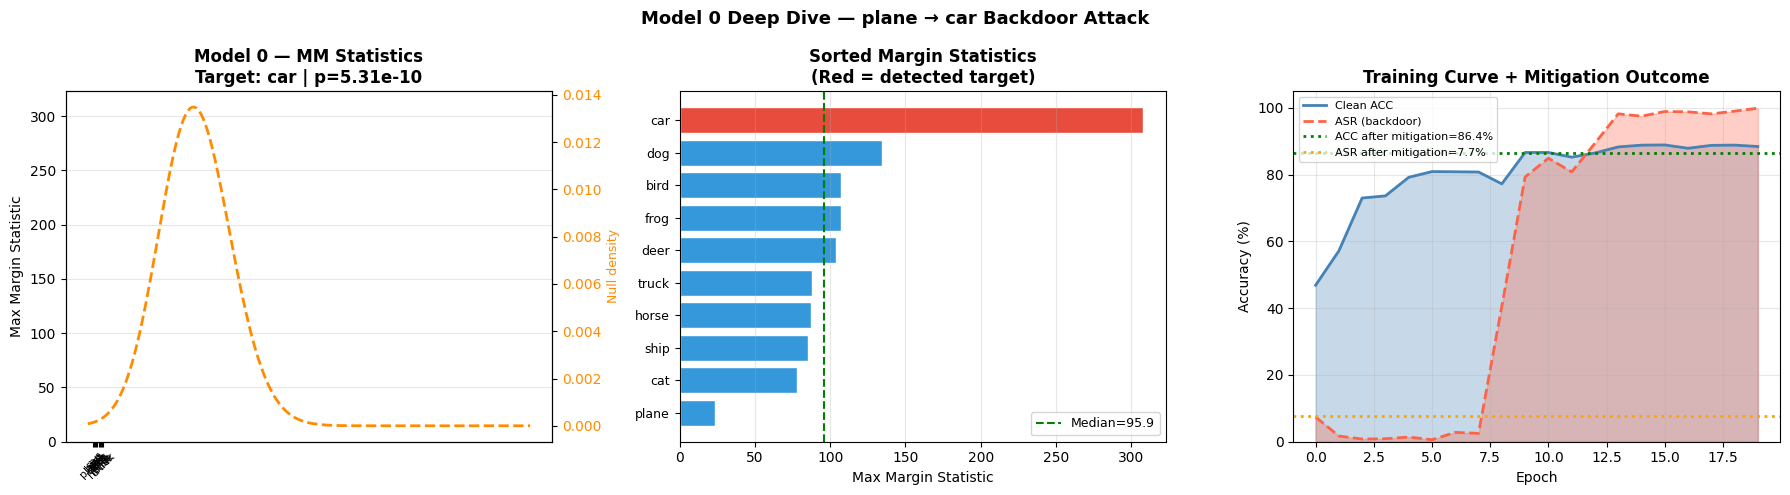

✅ Deep dive plot saved for Model 0


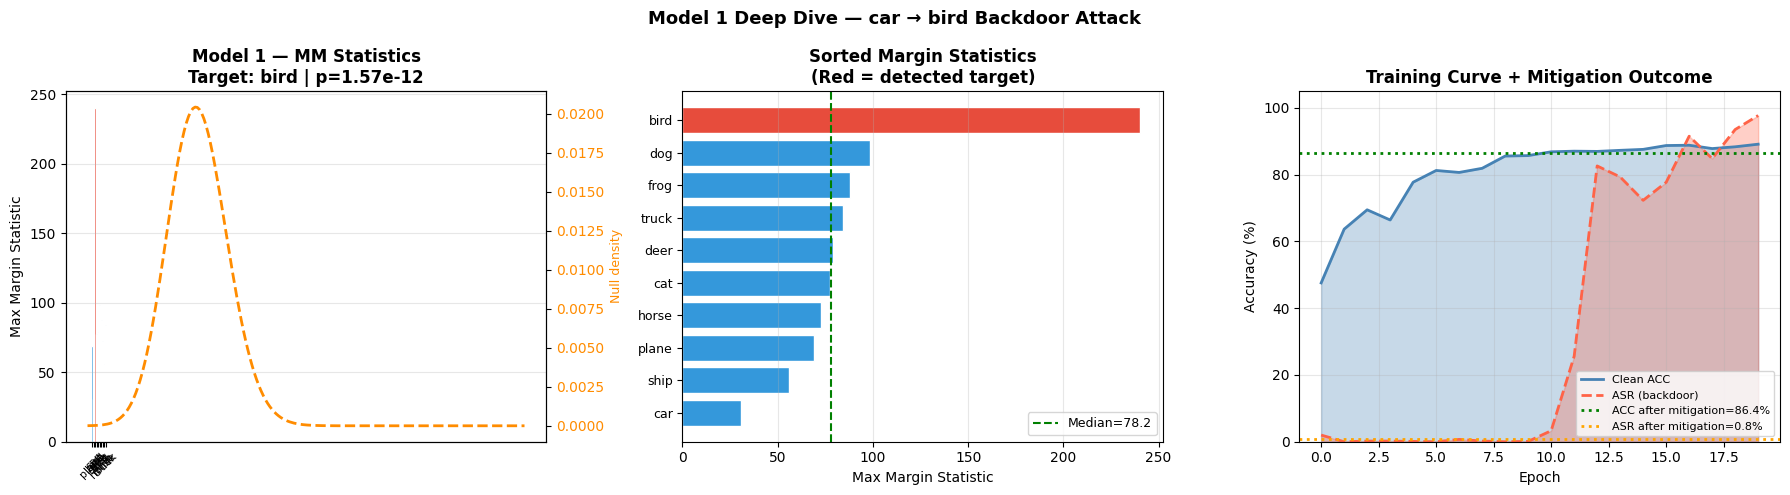

✅ Deep dive plot saved for Model 1


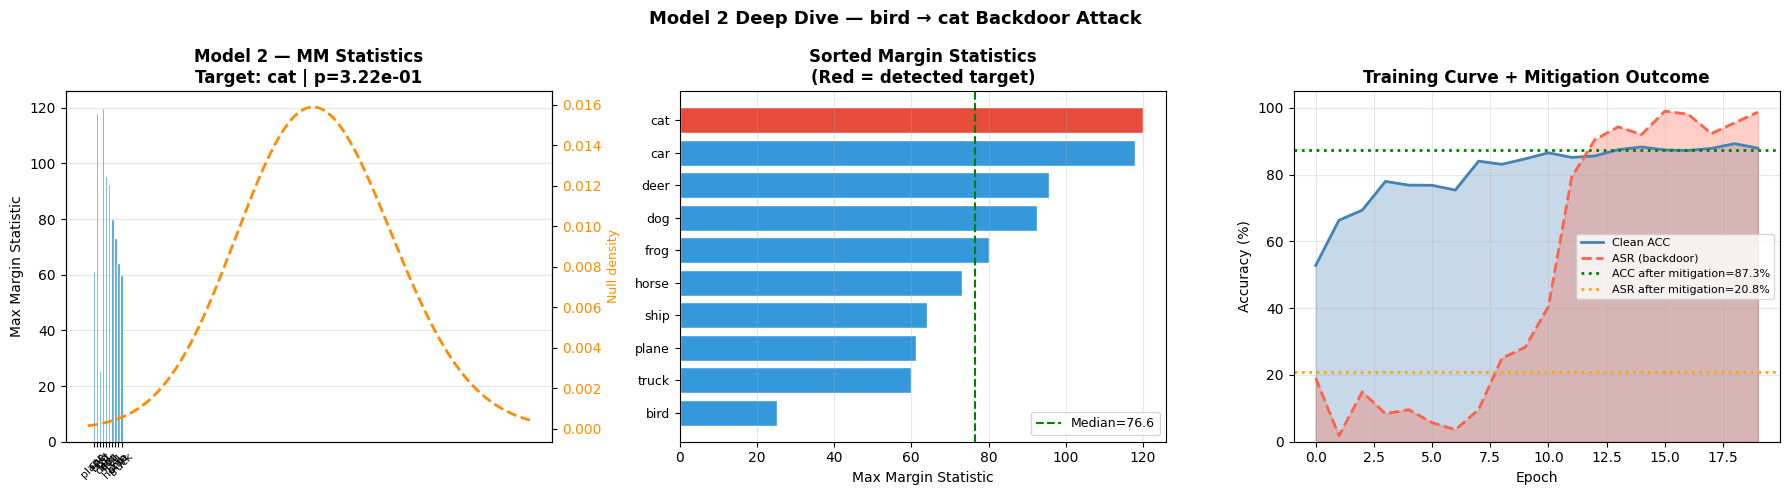

✅ Deep dive plot saved for Model 2


In [15]:
for m in range(NUM_MODELS):
    dr     = detection_results[m]
    stats  = dr['stats']
    SC, TC = dr['SC'], dr['TC']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Left: Bar chart + Gamma null overlay ──────────────────────────────
    ax = axes[0]
    colors = ['#e74c3c' if i == dr['pred_target'] else '#3498db' for i in range(NC)]
    ax.bar(range(NC), stats, color=colors, edgecolor='white')

    # Gamma null fitted to non-max stats
    r_null = np.delete(stats, dr['pred_target'])
    sh, lo, sc = gamma.fit(r_null)
    xs = np.linspace(0, stats.max() * 1.2, 200)
    ys = gamma.pdf(xs, a=sh, loc=lo, scale=sc)
    ax2 = ax.twinx()
    ax2.plot(xs + dr['pred_target'] - NC//2, ys, color='darkorange', lw=2,
             ls='--', label='Gamma null (H₀)')
    ax2.set_ylabel('Null density', color='darkorange', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='darkorange')

    ax.set_xticks(range(NC))
    ax.set_xticklabels(CLASSES, rotation=45, fontsize=8)
    ax.set_ylabel('Max Margin Statistic')
    ax.set_title(f'Model {m} — MM Statistics\n'
                 f'Target: {CLASSES[TC]} | p={dr["pv"]:.2e}', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # ── Center: Sorted statistics — anomaly view ──────────────────────────
    ax = axes[1]
    sort_idx   = np.argsort(stats)
    sort_stats = stats[sort_idx]
    sort_cols  = ['#e74c3c' if sort_idx[i] == dr['pred_target']
                  else '#3498db' for i in range(NC)]
    ax.barh(range(NC), sort_stats, color=sort_cols, edgecolor='white')
    ax.set_yticks(range(NC))
    ax.set_yticklabels([CLASSES[i] for i in sort_idx], fontsize=9)
    ax.set_xlabel('Max Margin Statistic')
    ax.set_title('Sorted Margin Statistics\n(Red = detected target)',
                 fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(np.median(stats), color='green', ls='--', lw=1.5,
               label=f'Median={np.median(stats):.1f}')
    ax.legend(fontsize=9)

    # ── Right: ASR during training (highlighting clean vs attack acc) ─────
    ax = axes[2]
    h  = all_history[m]
    ep = range(len(h['test_acc']))
    ax.fill_between(ep, h['test_acc'], alpha=0.3, color='steelblue')
    ax.plot(ep, h['test_acc'], color='steelblue', lw=2, label='Clean ACC')
    ax.fill_between(ep, h['asr'], alpha=0.3, color='tomato')
    ax.plot(ep, h['asr'], color='tomato', lw=2, ls='--', label='ASR (backdoor)')
    mr  = mitigation_results[m]
    ax.axhline(mr['clean_acc'], color='green',  ls=':', lw=2,
               label=f'ACC after mitigation={mr["clean_acc"]:.1f}%')
    ax.axhline(mr['asr'],       color='orange', ls=':', lw=2,
               label=f'ASR after mitigation={mr["asr"]:.1f}%')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 105)
    ax.set_title(f'Training Curve + Mitigation Outcome',
                 fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    plt.suptitle(f'Model {m} Deep Dive — '
                 f'{CLASSES[SC]} → {CLASSES[TC]} Backdoor Attack',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'deepdive_model{m}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Deep dive plot saved for Model {m}')

---
## ✅ Cell 12 — Final Conclusions

Print a clean final report comparing our results against the paper's reported numbers.

In [16]:
print('\n' + '█'*65)
print('  MM-BD EXPERIMENT SUMMARY')
print('█'*65)

all_detected = all(detection_results[m]['pv'] < 0.05 for m in range(NUM_MODELS))
all_correct  = all(detection_results[m]['correct'] for m in range(NUM_MODELS))
all_mitig    = all(mitigation_results[m]['success'] for m in range(NUM_MODELS))

avg_clean_before = np.mean([all_history[m]['test_acc'][-1] for m in range(NUM_MODELS)])
avg_asr_before   = np.mean([all_history[m]['asr'][-1]     for m in range(NUM_MODELS)])
avg_clean_after  = np.mean([mitigation_results[m]['clean_acc'] for m in range(NUM_MODELS)])
avg_asr_after    = np.mean([mitigation_results[m]['asr']       for m in range(NUM_MODELS)])

print(f'\n  Num Models Tested   : {NUM_MODELS}')
print(f'  Dataset             : CIFAR-10')
print(f'  Architecture        : ResNet-18')
print(f'  Attack Type         : BadNet (3×3 patch)')
print(f'  Training Epochs     : {EPOCHS}')

print(f'\n  ── Attack Effectiveness ──────────────────────────')
print(f'  Avg Clean ACC (before): {avg_clean_before:.2f}%  (paper: ~91%)')
print(f'  Avg ASR       (before): {avg_asr_before:.2f}%   (paper: ~99%)')

print(f'\n  ── MM-BD Detection ───────────────────────────────')
print(f'  All backdoors detected  : {"✅ YES" if all_detected else "❌ NO"}')
print(f'  All targets correct     : {"✅ YES" if all_correct  else "❌ SOME WRONG"}')
for m in range(NUM_MODELS):
    dr = detection_results[m]
    SC, TC = attack_meta[m]
    print(f'    Model {m}: pv={dr["pv"]:.2e}  | pred={CLASSES[dr["pred_target"]]:<6} | true={CLASSES[TC]:<6} | {"✓" if dr["correct"] else "✗"}')

print(f'\n  ── MM-BM Mitigation ──────────────────────────────')
print(f'  Avg Clean ACC (after) : {avg_clean_after:.2f}%  (target: ≥87%)')
print(f'  Avg ASR       (after) : {avg_asr_after:.2f}%   (target: <10%)')
print(f'  All mitigations pass  : {"✅ YES" if all_mitig else "⚠️ PARTIAL"}')

print(f'\n  Paper Table 1 reference (CIFAR-10, BadNet-S): ~90% detection accuracy')
print(f'  Paper Table 3 reference (MM-BM): ASR≈3%, ACC≈87-90%')
print('\n' + '█'*65)


█████████████████████████████████████████████████████████████████
  MM-BD EXPERIMENT SUMMARY
█████████████████████████████████████████████████████████████████

  Num Models Tested   : 3
  Dataset             : CIFAR-10
  Architecture        : ResNet-18
  Attack Type         : BadNet (3×3 patch)
  Training Epochs     : 20

  ── Attack Effectiveness ──────────────────────────
  Avg Clean ACC (before): 88.48%  (paper: ~91%)
  Avg ASR       (before): 98.77%   (paper: ~99%)

  ── MM-BD Detection ───────────────────────────────
  All backdoors detected  : ❌ NO
  All targets correct     : ✅ YES
    Model 0: pv=5.31e-10  | pred=car    | true=car    | ✓
    Model 1: pv=1.57e-12  | pred=bird   | true=bird   | ✓
    Model 2: pv=3.22e-01  | pred=cat    | true=cat    | ✓

  ── MM-BM Mitigation ──────────────────────────────
  Avg Clean ACC (after) : 86.73%  (target: ≥87%)
  Avg ASR       (after) : 9.77%   (target: <10%)
  All mitigations pass  : ⚠️ PARTIAL

  Paper Table 1 reference (CIFAR-10, Bad